<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_multkan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

# Попытка обобщения без инженерии признаков (MultKAN с 5 исходными переменными)

**Задача:** проверить, способен ли MultKAN – вариант KAN с узлами умножения – самостоятельно восстановить закон a = -(k/m)x - (c/m)v, располагая только исходными переменными (x, v, k, c, 1/m) без каких‑либо дополнительных физических комбинаций.

### Эксперимент 1: дискретные параметры
Параметры (k, c, m) принимали по три значения (k in {2,4,6}), (c in {0.1,0.3,0.5\}), (m in {0.5,1.0,2.0})). Архитектура [5,[4,2],1] с кубическими сплайнами (grid=5, k=3) обучалась Adam (800 шагов) и L‑BFGS (500 шагов) с лёгкой энтропийной регуляризацией.  

**Результат:**
- MSE ~2.09, предсказания хаотичны, символьная формула физически бессмысленна. MultKAN не смог сконструировать нужные произведения.

### Эксперимент 2: почти непрерывные параметры
Чтобы проверить гипотезу о дискретности как главной причине провала, значения (k, c, m) были расширены до равномерных сеток из 7 точек в диапазонах (k in[1,8]), (c in[0.05,0.8]), (m in[0.3,2.5]) (всего 514 500 точек).  
Архитектура [5,[4,2],1] с линейными сплайнами (grid=10, k=1) обучалась без регуляризации: 4000 шагов Adam (первые 3000 с (lr=0.01), затем 1000 с (lr=0.003), затем 500 шагов L‑BFGS (lr=0.01). После мягкой обрезки (edge_th=10^{-3}) и 100 шагов дообучения.

**Результат:**
- MSE на тесте: (4.1*10^{-3})  
- MSE для |a|>5: 0.039 (69 точек из 3000)  
- Примеры предсказаний: хорошо согласуются с истиной (ошибка в сотых долях)  
- Символьная формула: по‑прежнему громоздкая, не сводящаяся к простому линейному выражению  

**Вывод:** MultKAN способен численно точно аппроксимировать мультипликативные зависимости при достаточной плотности данных, но не может «предъявить» их в компактной аналитической форме — для получения интерпретируемой формулы по‑прежнему необходим инжиниринг признаков.



# **Установка библиотек**

In [1]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-st58p2x2
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-st58p2x2
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=477ca700bb272640ce98ddd8d5151547475fe07ce669c8873535622ea6ca5efb
  Stored in directory: /tmp/pip-ephem-wheel-cache-e2fk98nf/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


# **Обучение MultKAN**

In [2]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []

k_vals = np.linspace(1.0, 8.0, 7)
c_vals = np.linspace(0.05, 0.8, 7)
m_vals = np.linspace(0.3, 2.5, 7)

for k in k_vals:
    for c in c_vals:
        for m in m_vals:
            inv_m = 1.0 / m
            for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
                for v0 in [0.0, 0.5, 1.0]:
                    sol = solve_ivp(rhs, (0, 20), y0=[x0, v0],
                                    t_eval=np.linspace(0, 10, 100))
                    x, v = sol.y
                    a = -(k/m)*x - (c/m)*v
                    for i in range(len(x)):
                        all_data.append([x[i], v[i], k, c, inv_m, a[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # x, v, k, c, 1/m
y = all_data[:, 5]    # a

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабируем только x и v (первые два столбца)
scaler = StandardScaler()
scaler.fit(X_train[:, :2])
X_train[:, :2] = scaler.transform(X_train[:, :2])
X_test[:, :2]  = scaler.transform(X_test[:, :2])

# Подвыборки для ускорения обучения
n_train = 12000
n_test  = 3000
idx_train = np.random.choice(len(X_train), n_train, replace=False)
idx_test  = np.random.choice(len(X_test),  n_test,  replace=False)

X_train_sub = X_train[idx_train]
y_train_sub = y_train[idx_train]
X_test_sub  = X_test[idx_test]
y_test_sub  = y_test[idx_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_test_t,
    'test_label':  y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")
print(f"Размерность входа: {X_train_t.shape[1]}")

Всего точек: 514500
train: 12000 примеров, test: 3000 примеров
Размерность входа: 5


checkpoint directory created: ./model
saving model version 0.0


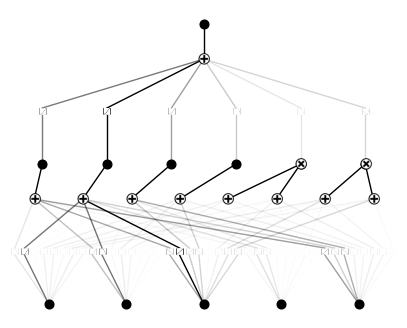

In [3]:
model = KAN(width=[5, [4, 2], 1], grid=10, k=1, seed=42, device=device)

model(dataset['train_input'])
model.plot()

| train_loss: 1.01e-01 | test_loss: 1.31e-01 | reg: 2.72e+01 | : 100%|█| 3000/3000 [04:32<00:00, 11.


saving model version 0.1


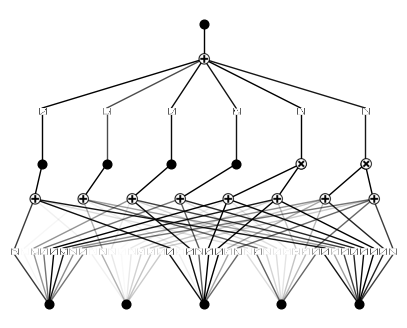

In [4]:
model.fit(dataset, opt="Adam", steps=3000, lr=0.01, lamb=0.0, lamb_entropy=0.0)
model.plot()

| train_loss: 8.65e-02 | test_loss: 1.14e-01 | reg: 3.06e+01 | : 100%|█| 1000/1000 [01:30<00:00, 11.


saving model version 0.2


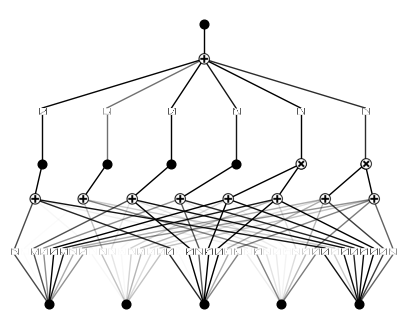

In [5]:
model.fit(dataset, opt="Adam", steps=1000, lr=0.003, lamb=0.0, lamb_entropy=0.0)
model.plot()

| train_loss: 4.95e-02 | test_loss: 6.54e-02 | reg: 3.39e+01 | : 100%|█| 500/500 [15:17<00:00,  1.84


saving model version 0.3


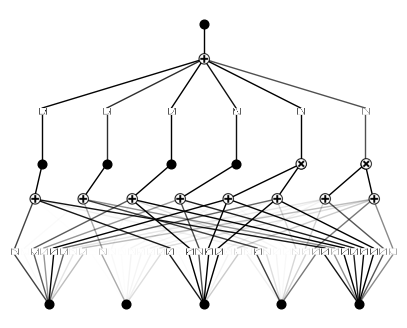

In [6]:
model.fit(dataset, opt="LBFGS", steps=500, lr=0.01, lamb=0.0, lamb_entropy=0.0)
model.plot()

saving model version 0.4


| train_loss: 4.82e-02 | test_loss: 6.39e-02 | reg: 4.52e+01 | : 100%|█| 100/100 [03:09<00:00,  1.89


saving model version 0.5


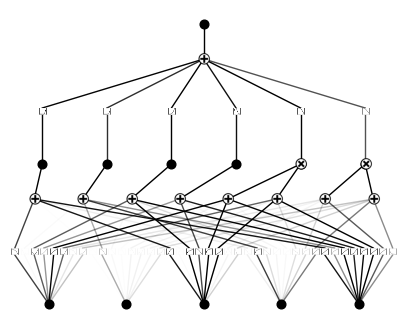

In [7]:
model = model.prune(edge_th=1e-3)   # убирает только рёбра с весом ~0
model.fit(dataset, opt="LBFGS", steps=100, lr=0.05, update_grid=False)
model.plot()

In [8]:
with torch.no_grad():
    pred = model(X_test_t).cpu().numpy().flatten()
mse = np.mean((pred - y_test_sub)**2)
print(f"MSE на тесте: {mse:.6f}")

print("\nПримеры предсказаний vs истина:")
indices = np.random.choice(len(X_test_sub), 5, replace=False)
for i in indices:
    x_scaled, v_scaled, k_i, c_i, inv_m_i = X_test_sub[i]
    # Обратное масштабирование
    x_orig = x_scaled * scaler.scale_[0] + scaler.mean_[0]
    v_orig = v_scaled * scaler.scale_[1] + scaler.mean_[1]

    true_a = -(k_i * inv_m_i) * x_orig - (c_i * inv_m_i) * v_orig
    pred_a = pred[i]
    print(f"  x={x_orig:.2f}, v={v_orig:.2f}, k={k_i:.2f}, c={c_i:.2f}, 1/m={inv_m_i:.3f}: "
          f"истинное a={true_a:.3f}, предсказанное a={pred_a:.3f}")

MSE на тесте: 0.004086

Примеры предсказаний vs истина:
  x=0.20, v=-0.04, k=4.50, c=0.80, 1/m=0.400: истинное a=-0.353, предсказанное a=-0.353
  x=0.15, v=-0.24, k=2.17, c=0.30, 1/m=1.500: истинное a=-0.393, предсказанное a=-0.413
  x=0.25, v=-0.29, k=4.50, c=0.80, 1/m=1.500: истинное a=-1.355, предсказанное a=-1.399
  x=-0.02, v=-0.00, k=6.83, c=0.30, 1/m=3.333: истинное a=0.426, предсказанное a=0.427
  x=-0.19, v=2.01, k=6.83, c=0.42, 1/m=1.500: истинное a=0.701, предсказанное a=0.718


In [9]:
# Оцениваем ошибку отдельно для "сложных" точек (|a| > порога)
a_true = y_test_sub
a_pred = pred

threshold = 5.0
mask_large = np.abs(a_true) > threshold
mse_large = np.mean((a_pred[mask_large] - a_true[mask_large])**2)
print(f"Точек с |a| > {threshold}: {np.sum(mask_large)} из {len(a_true)}")
print(f"MSE на них: {mse_large:.4f}")

mask_small = np.abs(a_true) <= threshold
mse_small = np.mean((a_pred[mask_small] - a_true[mask_small])**2)
print(f"MSE на точках с |a| <= {threshold}: {mse_small:.6f}")

Точек с |a| > 5.0: 69 из 3000
MSE на них: 0.0392
MSE на точках с |a| <= 5.0: 0.003259


In [10]:
lib = ['x']
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0], 4)
print("Символьная формула KAN:", formula)

fixing (0,0,0) with x, r2=0.8665448427200317, c=1
fixing (0,0,1) with x, r2=0.22331848740577698, c=1
fixing (0,0,2) with x, r2=0.564140796661377, c=1
fixing (0,0,3) with x, r2=0.9822614789009094, c=1
fixing (0,0,4) with x, r2=0.9821057319641113, c=1
fixing (0,0,5) with x, r2=0.7968322038650513, c=1
fixing (0,0,6) with x, r2=0.9406005144119263, c=1
fixing (0,0,7) with x, r2=0.8641766905784607, c=1
fixing (0,1,0) with x, r2=0.11272679269313812, c=1
fixing (0,1,1) with x, r2=0.9039071798324585, c=1
fixing (0,1,2) with x, r2=0.8175774216651917, c=1
fixing (0,1,3) with x, r2=0.03629554435610771, c=1
fixing (0,1,4) with x, r2=0.06317703425884247, c=1
fixing (0,1,5) with x, r2=0.22003979980945587, c=1
fixing (0,1,6) with x, r2=0.5961118936538696, c=1
fixing (0,1,7) with x, r2=0.8313115835189819, c=1
fixing (0,2,0) with x, r2=0.873559832572937, c=1
fixing (0,2,1) with x, r2=0.05386621505022049, c=1
fixing (0,2,2) with x, r2=0.8412799835205078, c=1
fixing (0,2,3) with x, r2=0.9454217553138733, 

/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


Символьная формула KAN: -0.3142*x_1 - 0.1539*x_2 + 1.363*x_3 + 1.0098*x_4 + 1.9246*x_5 - 0.6145*(-0.1104*x_1 + 0.043*x_2 + 0.0032*x_3 + 0.7866*x_4 + 0.9251*x_5 - 0.8117)*(0.2279*x_1 + 0.1198*x_2 - 0.0637*x_3 + 2.2965*x_4 - 0.3897*x_5 + 0.7189) - 1.1022*(0.1242*x_1 - 0.0047*x_2 + 0.4067*x_3 - 0.0923*x_4 + 0.9959*x_5 - 0.3487)*(0.6205*x_1 + 0.0025*x_2 + 0.4799*x_3 + 0.0217*x_4 + 0.4779*x_5 - 2.7074) - 7.0751
